In [1]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sb

# خواندن دیتاست تمیزشده
df = pd.read_csv("cleaned_covid_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Size:", df.shape)

Size: (35041, 10)


10 کشور با بیشترین موارد تأییدشده:
Country/Region
US                4290259
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     301708
Iran               293606
Name: Confirmed, dtype: int64


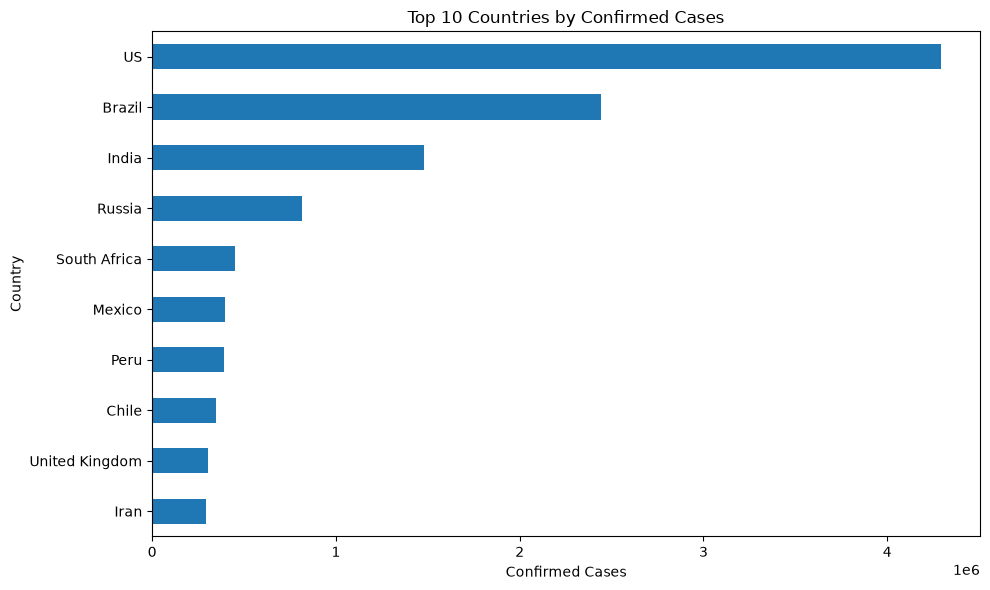

موارد تأییدشده در مناطق WHO:
WHO Region
Americas                 4290259
South-East Asia          1480073
Europe                    816680
Africa                    452529
Eastern Mediterranean     293606
Western Pacific            86783
Name: Confirmed, dtype: int64


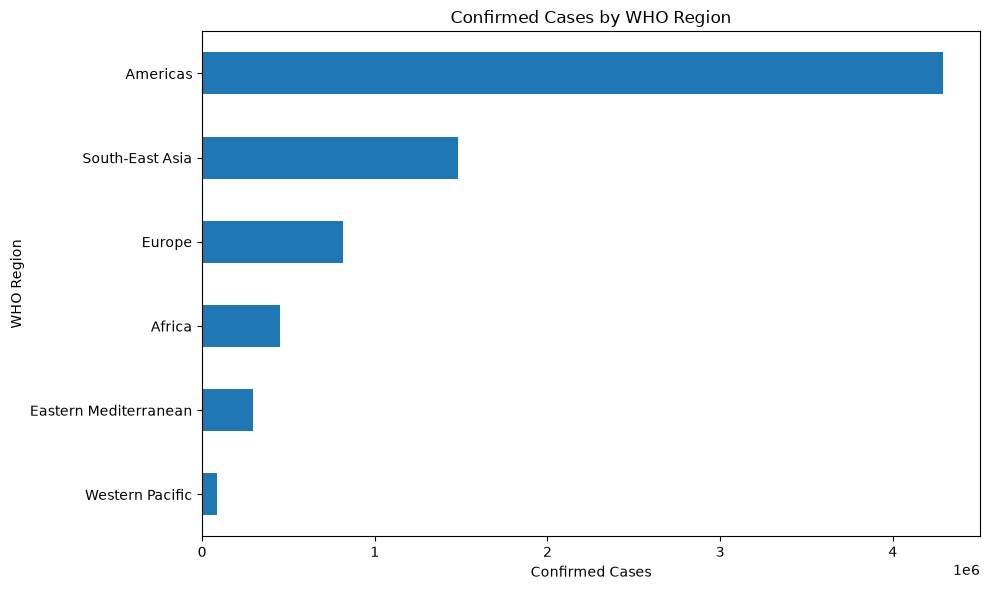

In [2]:
# مقایسه کشورها و مناطق

# مجموع موارد تأییدشده برای هر کشور
country_cases = (
    df.groupby("Country/Region")["Confirmed"]
    .max()
    .sort_values(ascending=False)
)

print("10 کشور با بیشترین موارد تأییدشده:")
print(country_cases.head(10))

# نمودار 10 کشور اول
pt.figure(figsize=(10, 6))
country_cases.head(10).sort_values().plot(kind="barh")

pt.title("Top 10 Countries by Confirmed Cases")
pt.xlabel("Confirmed Cases")
pt.ylabel("Country")
pt.tight_layout()
pt.show()

# مقایسه مناطق
region_cases = (
    df.groupby("WHO Region")["Confirmed"]
    .max()
    .sort_values(ascending=False)
)

print("موارد تأییدشده در مناطق WHO:")
print(region_cases)

pt.figure(figsize=(10, 6))
region_cases.sort_values().plot(kind="barh")

pt.title("Confirmed Cases by WHO Region")
pt.xlabel("Confirmed Cases")
pt.ylabel("WHO Region")
pt.tight_layout()
pt.show()

Pearson:
0.912


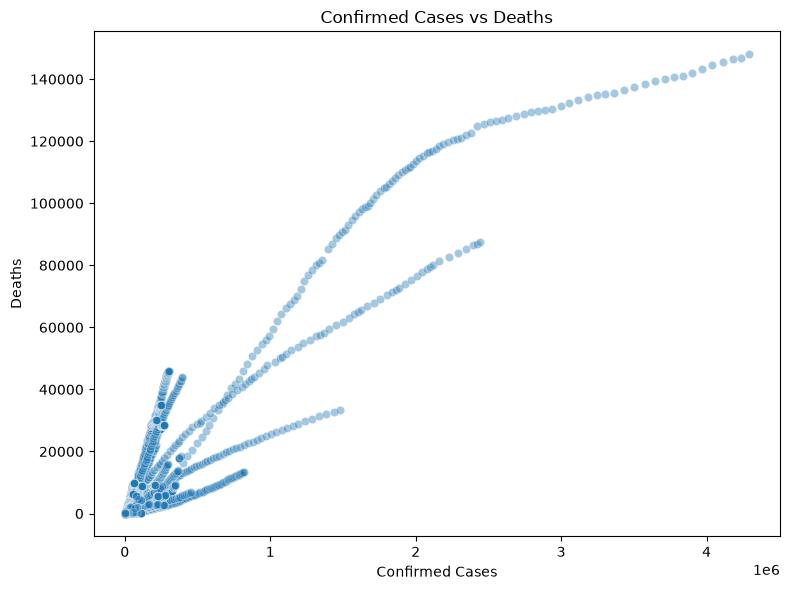

In [3]:
# رابطه موارد تأییدشده و مرگ

correlation = df["Confirmed"].corr(df["Deaths"])

print("Pearson:")
print(round(correlation, 3))

pt.figure(figsize=(8, 6))

sb.scatterplot(
    data=df,
    x="Confirmed",
    y="Deaths",
    alpha=0.4
)

pt.title("Confirmed Cases vs Deaths")
pt.xlabel("Confirmed Cases")
pt.ylabel("Deaths")
pt.tight_layout()
pt.show()

Most Cases in a Day:
282756
Date C/D:
2020-07-23


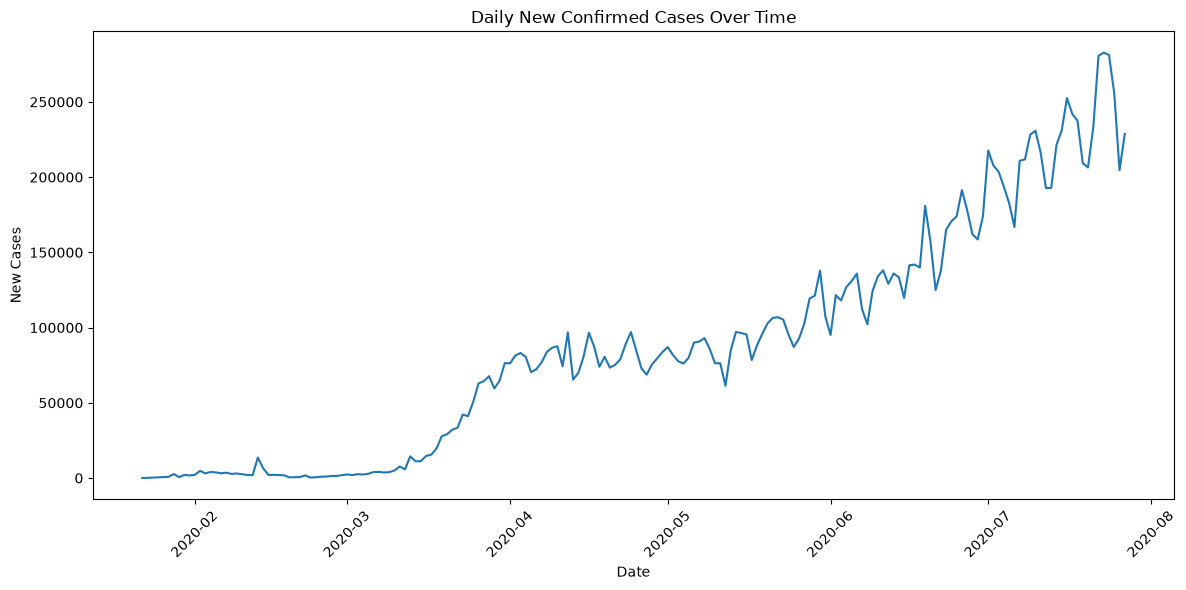

In [4]:
# روند زمانی موارد جدید

daily_cases = (
    df.groupby("Date")["New cases"]
    .sum()
    .sort_index()
)

print("Most Cases in a Day:")
print(daily_cases.max())

print("Date C/D:")
print(daily_cases.idxmax().date())

pt.figure(figsize=(12, 6))

pt.plot(
    daily_cases.index,
    daily_cases.values
)

pt.title("Daily New Confirmed Cases Over Time")
pt.xlabel("Date")
pt.ylabel("New Cases")
pt.xticks(rotation=45)
pt.tight_layout()
pt.show()

Confirmed:
count    3.504100e+04
mean     2.351692e+04
std      1.500045e+05
min      0.000000e+00
25%      1.000000e+00
50%      2.460000e+02
75%      3.623000e+03
max      4.290259e+06
Name: Confirmed, dtype: float64


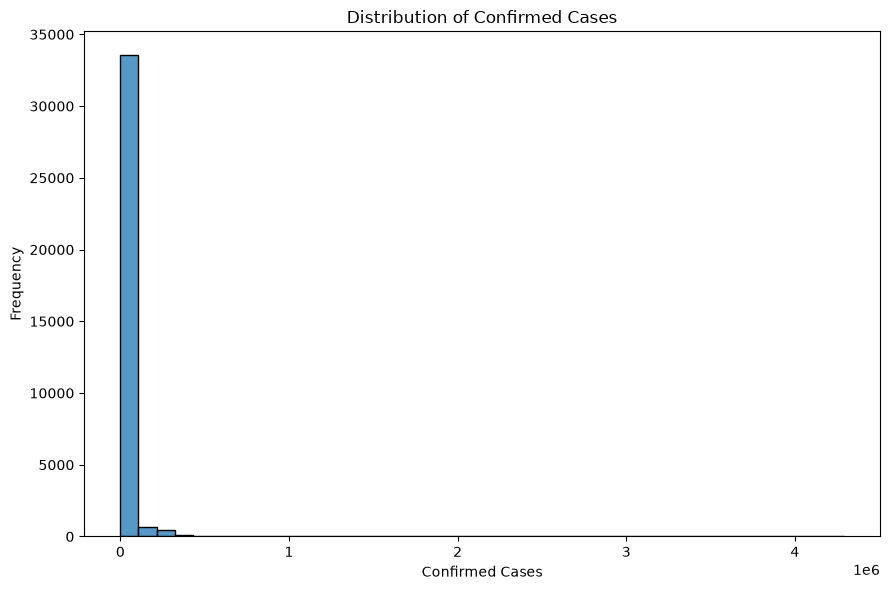

In [5]:
# توزیع موارد تأییدشده

print("Confirmed:")
print(df["Confirmed"].describe())

pt.figure(figsize=(9, 6))

sb.histplot(
    df["Confirmed"],
    bins=40
)

pt.title("Distribution of Confirmed Cases")
pt.xlabel("Confirmed Cases")
pt.ylabel("Frequency")
pt.tight_layout()
pt.show()

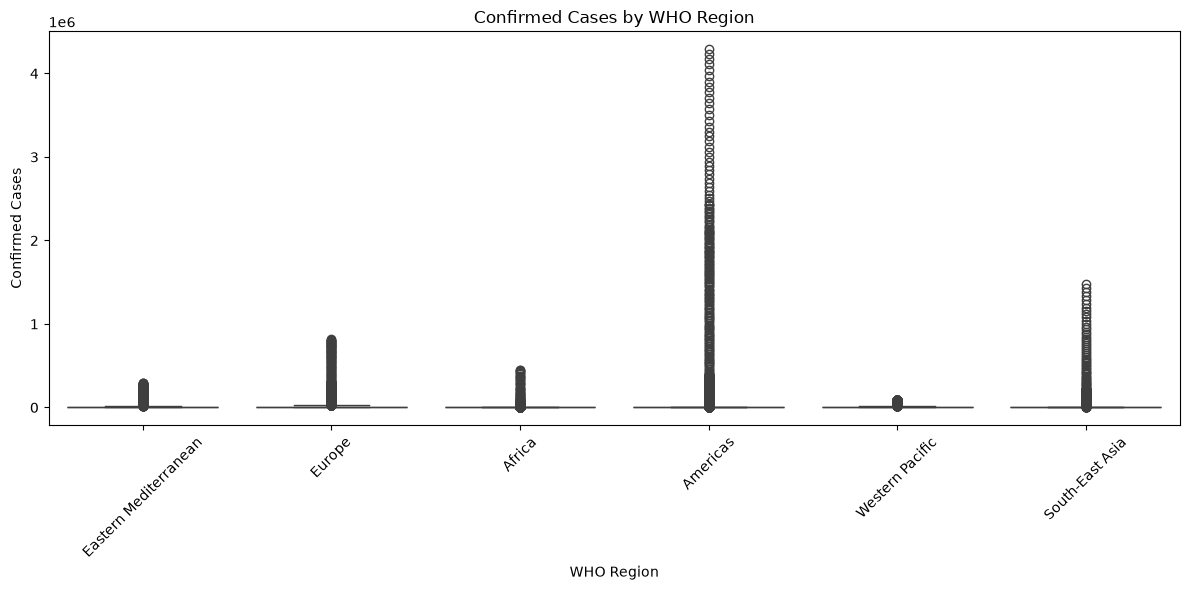

                       count          mean  median            std  min  \
WHO Region                                                               
Europe                 10459  23599.815183  1112.0   69918.070181    0   
Eastern Mediterranean   4129  17941.498910   727.0   45476.479249    0   
Western Pacific         2995   8761.588982   149.0   20365.963107    0   
South-East Asia         1877  29364.867342    86.0  131243.905839    0   
Americas                6568  60903.727923    78.5  321361.913875    0   
Africa                  9013   2415.522689    50.0   18229.547386    0   

                           max  
WHO Region                      
Europe                  816680  
Eastern Mediterranean   293606  
Western Pacific          86783  
South-East Asia        1480073  
Americas               4290259  
Africa                  452529  


In [6]:
# مقایسه گروه‌های WHO

pt.figure(figsize=(12, 6))

sb.boxplot(
    data=df,
    x="WHO Region",
    y="Confirmed")

pt.title("Confirmed Cases by WHO Region")
pt.xlabel("WHO Region")
pt.ylabel("Confirmed Cases")
pt.xticks(rotation=45)
pt.tight_layout()
pt.show()

# آمار هر منطقه برای مقایسه عددی

region_summary = (
    df.groupby("WHO Region")["Confirmed"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False))

print(region_summary)

In [7]:
# سؤال ۱: نسبت مرگ به موارد تأییدشده

country_rates = (
    df.groupby("Country/Region")[["Confirmed", "Deaths"]]
    .max()
)

country_rates["Death_Rate"] = (
    country_rates["Deaths"] / country_rates["Confirmed"] * 100
)

print("10 Countries with most Confirmed:")
print(
    country_rates["Death_Rate"]
    .sort_values(ascending=False)
    .head(10)
)

10 Countries with most Confirmed:
Country/Region
Yemen             28.562980
United Kingdom    15.194824
Belgium           14.785934
Italy             14.256596
France            13.710790
Hungary           13.399281
Netherlands       11.532773
Mexico            11.131030
Spain             10.554252
Western Sahara    10.000000
Name: Death_Rate, dtype: float64


In [8]:
# سؤال ۲: نسبت بهبودیافتگان به موارد تأییدشده

recovery_rates = (
    df.groupby("Country/Region")[["Confirmed", "Recovered"]]
    .max()
)

recovery_rates["Recovery_Rate"] = (
    recovery_rates["Recovered"] / recovery_rates["Confirmed"] * 100
)

print("10 Countries with most Recovered:")
print(
    recovery_rates["Recovery_Rate"]
    .sort_values(ascending=False)
    .head(10)
)

10 Countries with most Recovered:
Country/Region
Dominica       100.000000
Holy See       100.000000
Grenada        100.000000
Djibouti        98.379126
Iceland         98.327940
Brunei          97.872340
New Zealand     97.238279
Qatar           97.017254
Malaysia        96.597035
Mauritius       96.511628
Name: Recovery_Rate, dtype: float64


In [9]:
# سؤال ۳: نسبت موارد فعال به موارد تأییدشده

active_rates = (
    df.groupby("Country/Region")[["Confirmed", "Active"]]
    .max()
)

active_rates["Active_Rate"] = (
    active_rates["Active"] / active_rates["Confirmed"] * 100
)

print("10 Countries with most Active:")
print(
    active_rates["Active_Rate"]
    .sort_values(ascending=False)
    .head(10)
)

10 Countries with most Active:
Country/Region
Timor-Leste              100.000000
Mozambique                99.353322
Serbia                    97.750715
Laos                      95.000000
Namibia                   94.085730
Syria                     94.065282
Sweden                    92.820707
Canada                    92.319978
Botswana                  91.204330
Saint Kitts and Nevis     88.235294
Name: Active_Rate, dtype: float64


In [10]:
# سؤال ۴: بیشترین افزایش موارد تأییدشده در طول دوره

first_date = df["Date"].min()
last_date = df["Date"].max()

first_values = (
    df[df["Date"] == first_date]
    .set_index("Country/Region")["Confirmed"]
)

last_values = (
    df[df["Date"] == last_date]
    .set_index("Country/Region")["Confirmed"]
)

increase = (last_values - first_values).dropna()

print("10 Countries with most Confirmed:")
print(increase.sort_values(ascending=False).head(10))

print("First Date:", first_date.date())
print("Last Date:", last_date.date())

10 Countries with most Confirmed:
Country/Region
US                4290258
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     301708
Iran               293606
Name: Confirmed, dtype: int64
First Date: 2020-01-22
Last Date: 2020-07-27


In [11]:
# سؤال ۵: رابطه بین تعداد موارد و نرخ مرگ 

last_date = df["Date"].max()

last = df[df["Date"] == last_date].copy()

# محاسبه نرخ مرگ
last["CFR"] = (last["Deaths"] / last["Confirmed"]) * 100

# فقط کشورهایی که حداقل 1000 مورد تأییدشده دارند
filtered = last[last["Confirmed"] >= 1000].copy()

# همبستگی بین Confirmed و CFR
correlation = filtered["Confirmed"].corr(filtered["CFR"])

print("Least 10000 Cases", len(filtered))
print("Correlation Between Confirmed and CFR:", round(correlation, 4))

print("10 Countries with most CFR:")
print(
    filtered[
        ["Country/Region", "Confirmed", "Deaths", "CFR"]
    ]
    .sort_values("CFR", ascending=False)
    .head(10)
)

Least 10000 Cases 142
Correlation Between Confirmed and CFR: 0.0499
10 Countries with most CFR:
       Country/Region  Confirmed  Deaths        CFR
35038           Yemen       1691     483  28.562980
35031  United Kingdom     301708   45844  15.194824
34870         Belgium      66428    9822  14.785934
34939           Italy     246286   35112  14.256596
34915          France     220352   30212  13.710790
34931         Hungary       4448     596  13.399281
34974     Netherlands      53413    6160  11.532773
34965          Mexico     395489   44022  11.131030
35011           Spain     272421   28432  10.436787
34886          Canada     116458    8944   7.680022
